In [ ]:
import pandas as pd, matplotlib.pyplot as plt, os
os.makedirs('../reports/figures', exist_ok=True)
train_df = pd.read_pickle('../data/processed/train_df.pkl')
test_df  = pd.read_pickle('../data/processed/test_df.pkl')

In [ ]:
print("Labels TRAIN " )
print(train_df['label'].value_counts())
print("\n=== 5 familles TRAIN ===")
order=['normal','dos','probe','r2l','u2r']
counts=train_df['attack_family'].value_counts().reindex(order)
for f,c in counts.items(): print(f"{f:7s} | {c:>6,} ({100*c/counts.sum():.1f}%)")

=== Labels TRAIN ===
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

=== 5 familles TRAIN ===
normal  | 67,343 (53.5%)
dos     | 45,927 (36.5%)
probe   | 11,656 (9.3%)
r2l     |    995 (0.8%)
u2r     |     52 (0.0%)


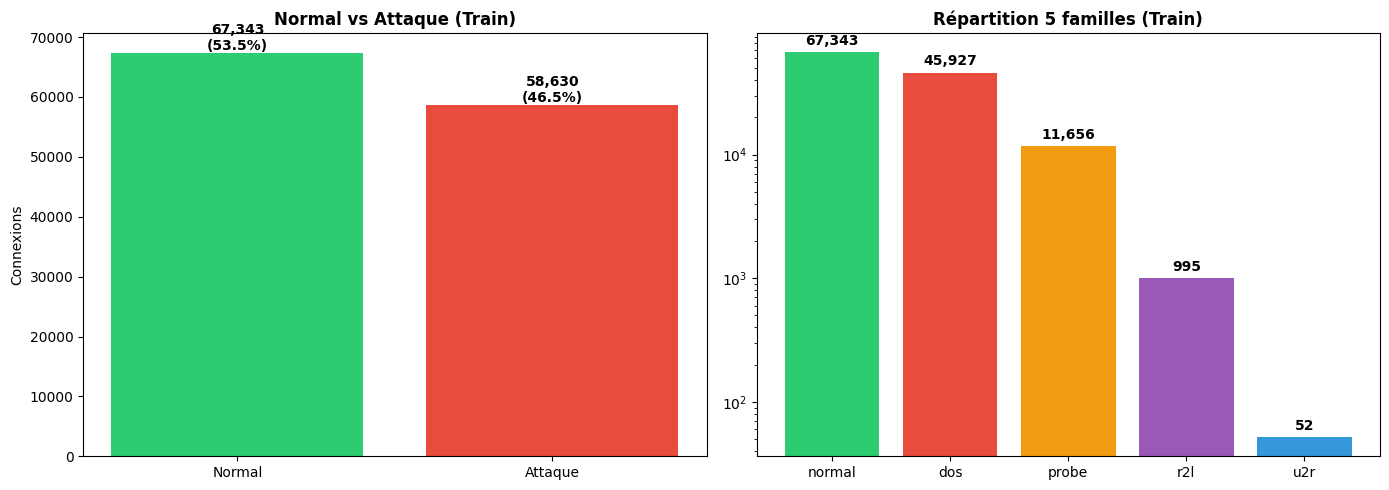

In [3]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
nn=(train_df['binary_label']==0).sum(); na=(train_df['binary_label']==1).sum()
axes[0].bar(['Normal','Attaque'],[nn,na],color=['#2ecc71','#e74c3c'])
axes[0].set_title('Normal vs Attaque (Train)',fontweight='bold'); axes[0].set_ylabel('Connexions')
for i,v in enumerate([nn,na]): axes[0].text(i,v+500,f'{v:,}\n({100*v/(nn+na):.1f}%)',ha='center',fontweight='bold')
axes[1].bar(order,counts.values,color=['#2ecc71','#e74c3c','#f39c12','#9b59b6','#3498db'])
axes[1].set_yscale('log'); axes[1].set_title('Répartition 5 familles (Train)',fontweight='bold')
for i,v in enumerate(counts.values): axes[1].text(i,v*1.15,f'{v:,}',ha='center',fontweight='bold')
plt.tight_layout(); plt.savefig('../reports/figures/distribution.png',dpi=150,bbox_inches='tight'); plt.show()